Step 1 - Import Libraries and Machine Learning Dependencies.
         Load all required Python packages for data manipulation, visualization, 
         preprocessing, model building, evaluation, and ensemble learning.


In [1]:
# Step 1: Import Libraries and Machine Learning Dependencies

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier
)


Step 2 - Load and Inspect Dataset Files.
         Import the training, testing, and submission datasets Pandas          DataFrames and verify file dimensions.

In [2]:
# Step 2: Load Training and Test Datasets

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
submission = pd.read_csv("sample_submission.csv")

print(train.shape)
print(test.shape)

train.head()


(20758, 18)
(13840, 17)


,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


Step3 -  Perform Initial Data Exploration (EDA).
         Examine dataset structure, feature types, dataset size,                summary statistics, and identify any missing values or                anomalies.

In [3]:
# Step 3: Perform Initial Data Exploration (EDA)

train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   Gender                          20758 non-null  object 
 2   Age                             20758 non-null  float64
 3   Height                          20758 non-null  float64
 4   Weight                          20758 non-null  float64
 5   family_history_with_overweight  20758 non-null  object 
 6   FAVC                            20758 non-null  object 
 7   FCVC                            20758 non-null  float64
 8   NCP                             20758 non-null  float64
 9   CAEC                            20758 non-null  object 
 10  SMOKE                           20758 non-null  object 
 11  CH2O                            20758 non-null  float64
 12  SCC                             

,id,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,20758.00000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000
mean,10378.50000,23.841804,1.700245,87.887768,2.445908,2.761332,2.029418,0.981747,0.616756
std,5992.46278,5.688072,0.087312,26.379443,0.533218,0.705375,0.608467,0.838302,0.602113
min,0.00000,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,5189.25000,20.000000,1.631856,66.000000,2.000000,3.000000,1.792022,0.008013,0.000000
50%,10378.50000,22.815416,1.700000,84.064875,2.393837,3.000000,2.000000,1.000000,0.573887
75%,15567.75000,26.000000,1.762887,111.600553,3.000000,3.000000,2.549617,1.587406,1.000000
max,20757.00000,61.000000,1.975663,165.057269,3.000000,4.000000,3.000000,3.000000,2.000000


Step 4 - Analyze Numerical Feature Relationships
         Create a correlation heatmap to identify relationships and            dependencies among numerical variables.

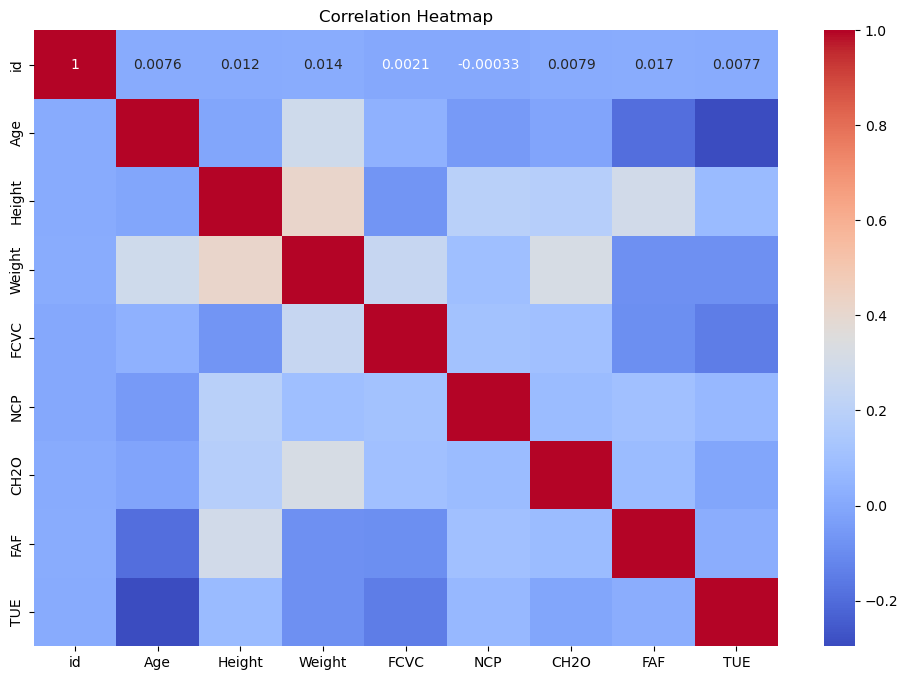

In [4]:
# Step 4 Analyze Numerical Feature Relationships

plt.figure(figsize=(12,8))
sns.heatmap(train.corr(numeric_only=True),
cmap='coolwarm',
annot=True)
plt.title("Correlation Heatmap")

plt.savefig("Obesity-Risk-Classification-Ensemble-Models/MODEL 2_BAGGING SUBMISSION/reports/figures/correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

Step 5 - Explore Feature Distributions.
         Visualize numerical variables using histograms to understand          distribution patterns, skewness, and potential outliers.

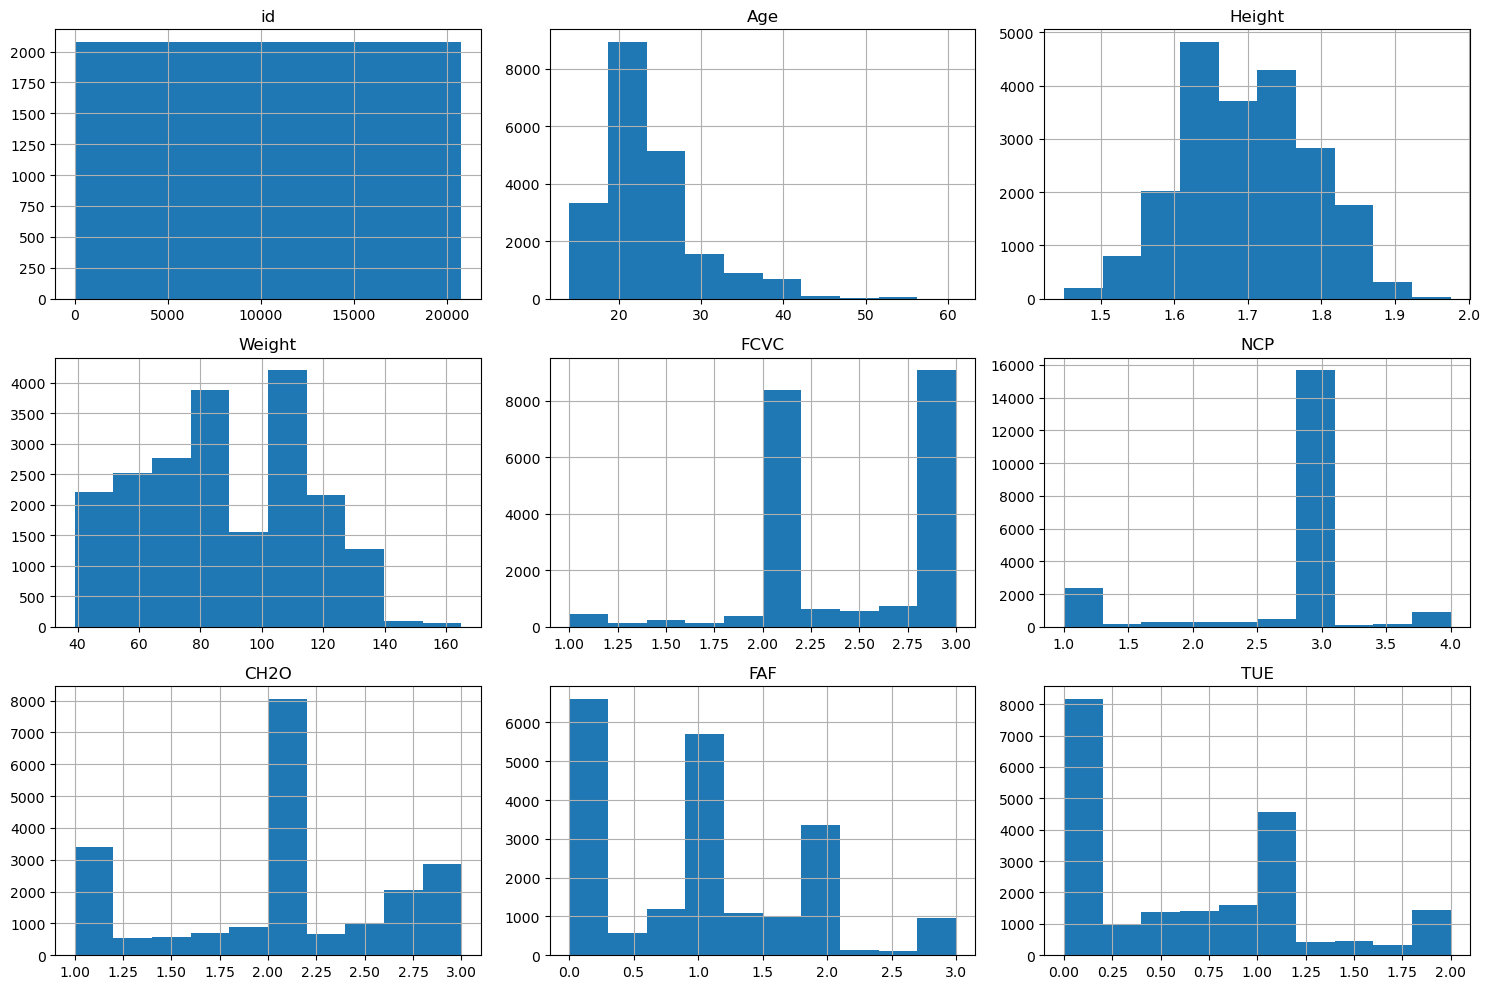

In [5]:
# Step 5: Explore Feature Distributions

train.hist(figsize=(15,10))
plt.tight_layout()

plt.savefig("Obesity-Risk-Classification-Ensemble-Models/MODEL 2_BAGGING SUBMISSION/reports/figures/feature_distributions.png", dpi=300, bbox_inches="tight")

plt.show()

Step 6 -  Assess Target Class Balance.
          Examine the distribution of obesity categories to determine           whether class imbalance exists before training.

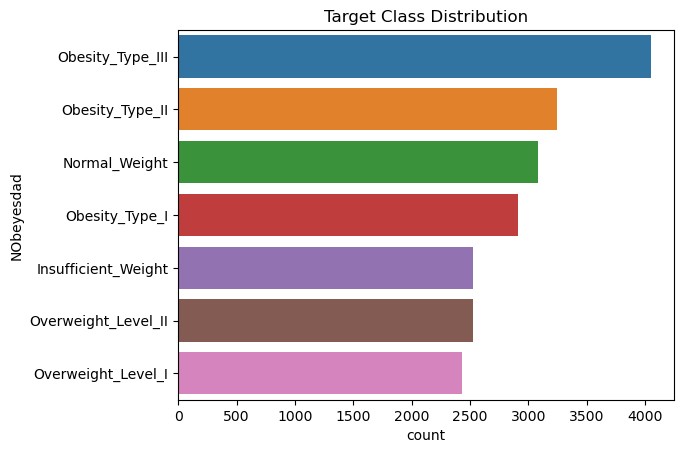

In [6]:
# Step 6: Assess Target Class Balance

sns.countplot(
    y='NObeyesdad',
    data=train,
    order=train['NObeyesdad'].value_counts().index
)

plt.title("Target Class Distribution")

plt.savefig("Obesity-Risk-Classification-Ensemble-Models/MODEL 2_BAGGING SUBMISSION/reports/figures/class_distribution.png", dpi=300, bbox_inches="tight")

plt.show()


Step 7 -  Encode Categorical Features and Prepare Modeling Data.
          Convert categorical variables into numerical format, encode           the target variable, and prepare training and testing                 feature sets.

In [7]:
# Step 7: Encode Categorical Features and Prepare Modeling Data

combined = pd.concat([train.drop("NObeyesdad", axis=1), test])

categorical_cols = combined.select_dtypes(include=["object"]).columns

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    combined[col] = le.fit_transform(combined[col])
    encoders[col] = le

X_train_full = combined.iloc[:len(train)]
X_test = combined.iloc[len(train):]

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(train["NObeyesdad"])


Step 8 -  Create Training and Validation Datasets.
          Split the encoded training data into training and validation           subsets for unbiased model evaluation.

In [8]:
# Step 8: Create Training and Validation Datasets

from sklearn.model_selection import train_test_split

# Split the full training data into train and validation sets

X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y, test_size=0.2, random_state=42)




Step 9 - Build and Train the Bagging Ensemble Model.
         Train a BaggingClassifier using Decision Trees as base                learners to improve prediction stability and accuracy.

In [9]:
# Step 9: Build and Train the Bagging Ensemble Model

bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

bag_model.fit(X_train, y_train)


BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=300,
                  n_jobs=-1, random_state=42)

Step 10 -  Evaluate Validation Accuracy. 
           Measure overall predictive performance using accuracy on the 
           validation dataset. The notebook reports approximately 89.21% accuracy.
           

In [10]:
# Step 10: Evaluate Validation Accuracy

bag_preds = bag_model.predict(X_valid)

print(accuracy_score(y_valid, bag_preds))


0.8921001926782274


Step 11: Visualize Classification Performance with Confusion Matrix.
         Display prediction results across classes and identify where          misclassifications occur.
       

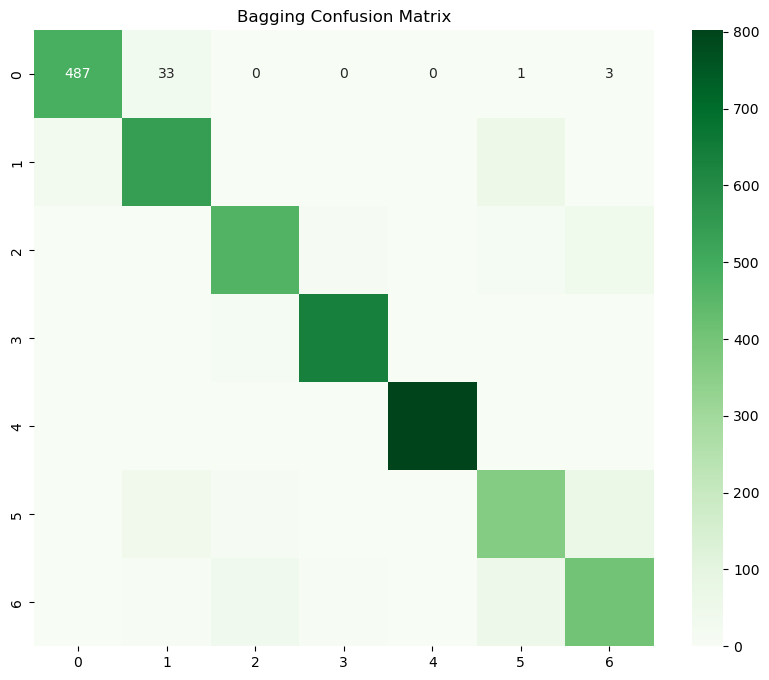

In [11]:
# Step 11: Visualize Classification Performance with Confusion Matrix

plt.figure(figsize=(10, 8))

sns.heatmap(
    confusion_matrix(y_valid, bag_preds),
    annot=True,
    cmap='Greens',
    fmt='d'
)

plt.title("Bagging Confusion Matrix")

plt.savefig("Obesity-Risk-Classification-Ensemble-Models/MODEL 2_BAGGING SUBMISSION/reports/figures/bagging_confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()


Step 12: Generate Detailed Classification Metrics Report.
         Evaluate precision, recall, F1-score, and support for each obesity class.
         

In [12]:
# Step 12: Generate Detailed Classification Metrics Report

print(
classification_report(
y_valid,
bag_preds
)
)

              precision    recall  f1-score   support

           0       0.94      0.93      0.94       524
           1       0.87      0.86      0.87       626
           2       0.87      0.86      0.87       543
           3       0.97      0.97      0.97       657
           4       1.00      1.00      1.00       804
           5       0.74      0.75      0.74       484
           6       0.77      0.79      0.78       514

    accuracy                           0.89      4152
   macro avg       0.88      0.88      0.88      4152
weighted avg       0.89      0.89      0.89      4152



Step 13 - Analyze Feature Importance and Model Drivers.
          Estimate which predictors contribute most to classification decisions in the Bagging model.
        

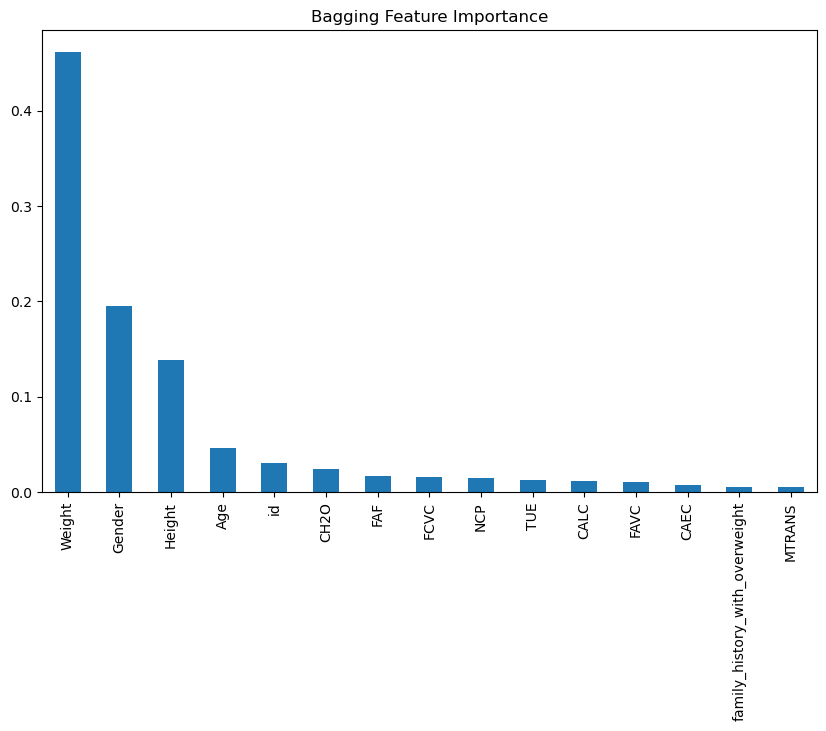

In [13]:
# Step 13: Analyze Feature Importance and Model Drivers

importances = np.mean(
    [tree.feature_importances_ for tree in bag_model.estimators_],
    axis=0
)

pd.Series(
    importances,
    index=X_train.columns
).sort_values(
    ascending=False
).head(15).plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Bagging Feature Importance")

plt.savefig("Obesity-Risk-Classification-Ensemble-Models/MODEL 2_BAGGING SUBMISSION/reports/figures/bagging_feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()


Step 14 - Generate Test Predictions and Export Kaggle Submission.
          Predict obesity classes for the test dataset and save the 
          final submission file for Kaggle upload

In [14]:
# Step 14: Generate Test Predictions and Export Kaggle Submission #2

bag_test_preds = bag_model.predict(X_test)

submission['NObeyesdad'] = target_encoder.inverse_transform(bag_test_preds)

submission.to_csv(
    "submission_bagging.csv",
    index=False
)
